In [17]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

#Import CSV data as pandas Dataframe

In [18]:
df= pd.read_csv('raw.csv')

In [19]:
df.head(10)

,id,Name,Gender,Age,Section,Science,English,History,Maths
0,1,Bronnie,Female,13,C,21,81,62,49
1,2,Lemmie,Male,15,B,29,41,17,40
2,3,Danya,Female,14,C,12,87,16,96
3,4,Denna,Female,14,B,15,53,82,33
4,5,Jocelin,Male,14,A,43,6,3,21
5,6,Malissa,Female,14,C,98,51,85,76
6,7,Ichabod,Female,14,B,38,74,54,60
7,8,Beverlie,Male,14,B,25,51,41,80
8,9,Corrine,Male,15,A,39,16,22,49
9,10,Tate,Male,15,C,35,25,37,27


In [20]:
df.shape

(250, 9)

checking if any duplicate values in a dataset
##using df.isna()--> gives the whole data and write "True" for "null" values and "False" for "not null" values
##using df.isna().sum()--> gives the total null values in a dataset columnwise 

In [21]:
df.isna().sum()

id         0
Name       0
Gender     0
Age        0
Section    0
Science    0
English    0
History    0
Maths      0
dtype: int64

checking duplicate values

In [22]:
df.duplicated().sum()

np.int64(0)

checking the types of values in a dataset 

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       250 non-null    int64 
 1   Name     250 non-null    object
 2   Gender   250 non-null    object
 3   Age      250 non-null    int64 
 4   Section  250 non-null    object
 5   Science  250 non-null    int64 
 6   English  250 non-null    int64 
 7   History  250 non-null    int64 
 8   Maths    250 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 17.7+ KB


checking the number of unique values of each column

In [24]:
df.nunique()

id         250
Name       247
Gender       2
Age          3
Section      3
Science     91
English     93
History     91
Maths       93
dtype: int64

statistics of dataset

In [25]:
df.describe()

,id,Age,Science,English,History,Maths
count,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000
mean,125.500000,14.020000,51.440000,47.980000,52.272000,53.016000
std,72.312977,0.823598,29.314497,29.949013,26.868526,27.386416
min,1.000000,13.000000,1.000000,1.000000,1.000000,1.000000
25%,63.250000,13.000000,25.250000,20.250000,31.000000,30.000000
50%,125.500000,14.000000,53.000000,47.500000,53.000000,52.500000
75%,187.750000,15.000000,78.000000,74.000000,76.000000,76.000000
max,250.000000,15.000000,100.000000,100.000000,100.000000,100.000000


In [26]:
df.head()

,id,Name,Gender,Age,Section,Science,English,History,Maths
0,1,Bronnie,Female,13,C,21,81,62,49
1,2,Lemmie,Male,15,B,29,41,17,40
2,3,Danya,Female,14,C,12,87,16,96
3,4,Denna,Female,14,B,15,53,82,33
4,5,Jocelin,Male,14,A,43,6,3,21


#finding data based on categories 

In [27]:
#categories in gender
print(f"Categories in 'gender' column: ",df['Gender'].unique())

#Type of sections
print(f"Categories in 'section': ", df["Section"].unique())

Categories in 'gender' column:  ['Female' 'Male']
Categories in 'section':  ['C' 'B' 'A']


In [28]:
#define numerical and categorical features in a dataset
numerical_features=[feature for feature in df.columns if df[feature].dtype!="O"]
categorical_features=[feature for feature in df.columns if df[feature].dtype=="O"]

#printing the numerical and categorical features
print(f"we have {len(numerical_features)} numerical features in a dataset: {numerical_features}")
print(f"we have {len(categorical_features)} categorical features in a dataset: {categorical_features}")

we have 6 numerical features in a dataset: ['id', 'Age', 'Science', 'English', 'History', 'Maths']
we have 3 categorical features in a dataset: ['Name', 'Gender', 'Section']


#Adding columns "Total Scores" and "Average"

In [29]:
df['Total Score']=df['Science'] + df['History'] + df['English'] + df['Maths']
df['Average']= df['Total Score']/4

In [30]:
df.head(10)

,id,Name,Gender,Age,Section,Science,English,History,Maths,Total Score,Average
0,1,Bronnie,Female,13,C,21,81,62,49,213,53.25
1,2,Lemmie,Male,15,B,29,41,17,40,127,31.75
2,3,Danya,Female,14,C,12,87,16,96,211,52.75
3,4,Denna,Female,14,B,15,53,82,33,183,45.75
4,5,Jocelin,Male,14,A,43,6,3,21,73,18.25
5,6,Malissa,Female,14,C,98,51,85,76,310,77.50
6,7,Ichabod,Female,14,B,38,74,54,60,226,56.50
7,8,Beverlie,Male,14,B,25,51,41,80,197,49.25
8,9,Corrine,Male,15,A,39,16,22,49,126,31.50
9,10,Tate,Male,15,C,35,25,37,27,124,31.00


Insights:
who have scored 100 out of 100

In [31]:
#History
history_score=df[df['History']==100]['Average'].count()
print("The Total students who have scored more than 100: ", history_score)

#Science
science_score=df[df['Science']==100]['Average'].count()
print("The Total students who have scored more than 100: ", science_score)

#English
English_score=df[df['English']==100]['Average'].count()
print("The Total students who have scored more than 100: ", English_score)

#Maths
maths_score=df[df['Maths']==100]['Average'].count()
print("The Total students who have scored more than 100: ", maths_score)


The Total students who have scored more than 100:  1
The Total students who have scored more than 100:  4
The Total students who have scored more than 100:  3
The Total students who have scored more than 100:  3


Score less than or equal to passing marks 33

In [32]:
#History
history_score_33=df[df['History']<=33]['Average'].count()
print("The Total students who have scored more than 100: ", history_score_33)

#Science
science_score_33=df[df['Science']<=33]['Average'].count()
print("The Total students who have scored more than 100: ", science_score_33)

#English
English_score_33=df[df['English']<=33]['Average'].count()
print("The Total students who have scored more than 100: ", English_score_33)

#Maths
maths_score_33=df[df['Maths']<=33]['Average'].count()
print("The Total students who have scored more than 100: ", maths_score_33)


The Total students who have scored more than 100:  71
The Total students who have scored more than 100:  80
The Total students who have scored more than 100:  93
The Total students who have scored more than 100:  72


In [33]:
df.head()

,id,Name,Gender,Age,Section,Science,English,History,Maths,Total Score,Average
0,1,Bronnie,Female,13,C,21,81,62,49,213,53.25
1,2,Lemmie,Male,15,B,29,41,17,40,127,31.75
2,3,Danya,Female,14,C,12,87,16,96,211,52.75
3,4,Denna,Female,14,B,15,53,82,33,183,45.75
4,5,Jocelin,Male,14,A,43,6,3,21,73,18.25


Histogram & KDE

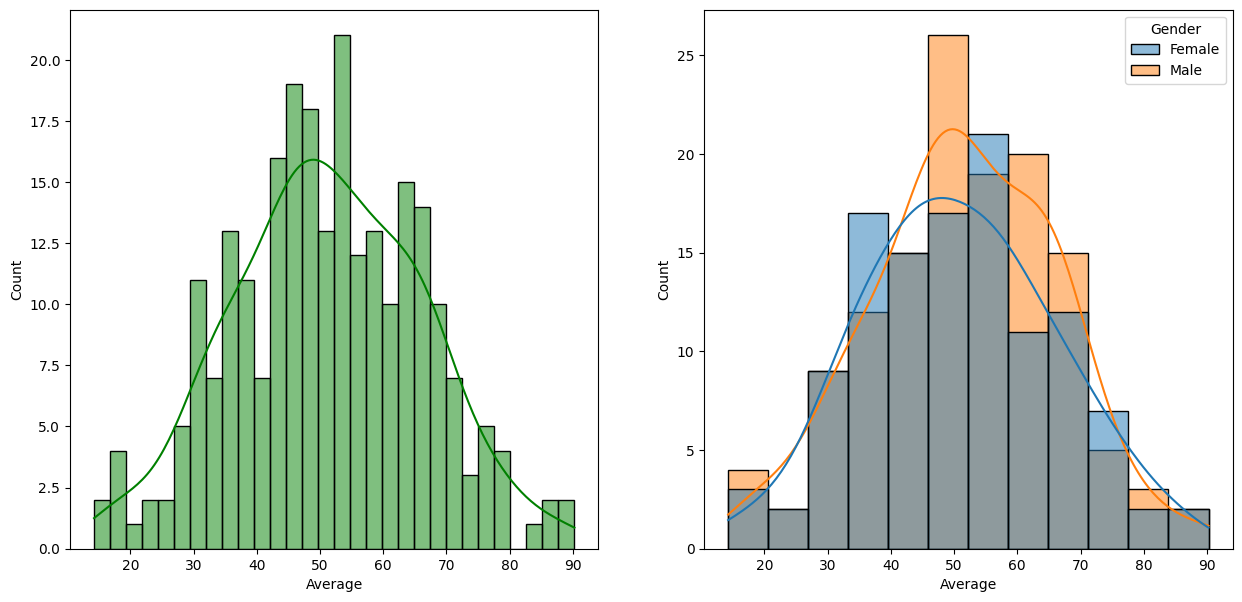

In [35]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='Average',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='Average',kde=True,hue='Gender')
plt.show()

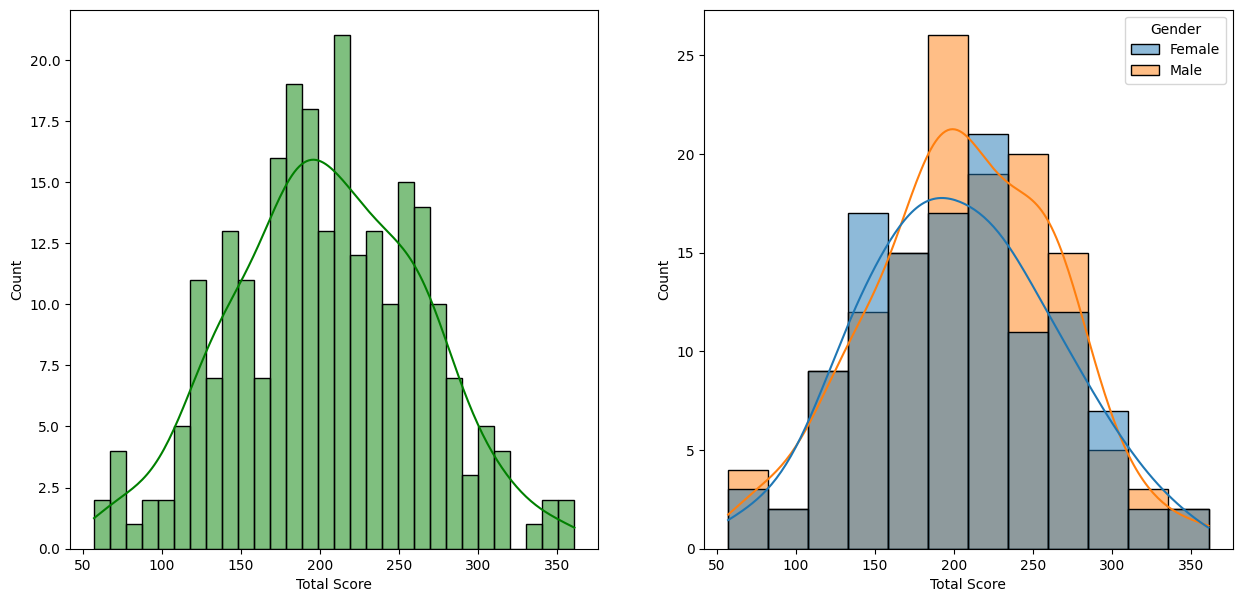

In [38]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='Total Score',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='Total Score',kde=True,hue='Gender')
plt.show()

Insight: Female students tend to perform well than male friends

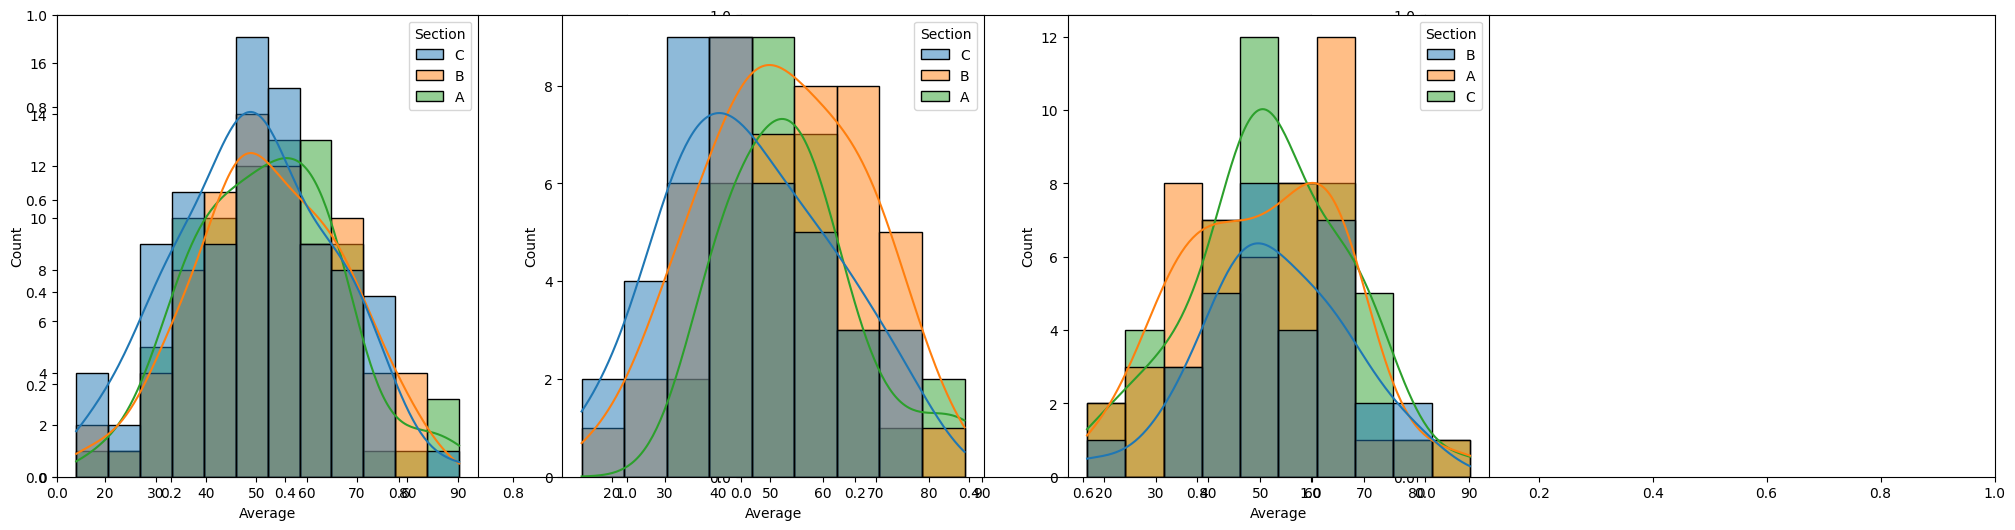

In [43]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df,x='Average',kde=True,hue='Section')
plt.subplot(142)
sns.histplot(data=df[df.Gender=='Female'],x='Average',kde=True,hue='Section')
plt.subplot(143)
sns.histplot(data=df[df.Gender=='Male'],x='Average',kde=True,hue='Section')
plt.show()

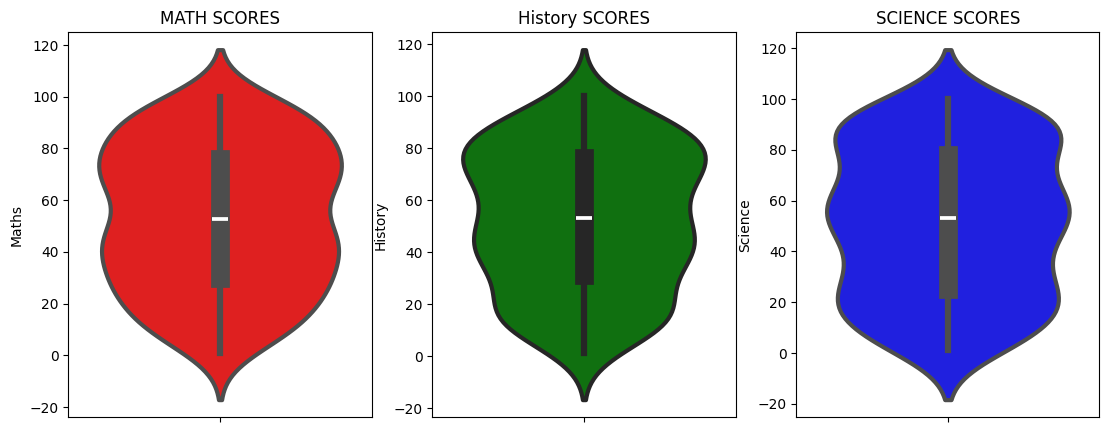

In [46]:
plt.figure(figsize=(18,5))
plt.subplot(1, 4, 1)
plt.title('MATH SCORES')
sns.violinplot(y='Maths',data=df,color='red',linewidth=3)
plt.subplot(1, 4, 2)
plt.title('History SCORES')
sns.violinplot(y='History',data=df,color='green',linewidth=3)
plt.subplot(1, 4, 3)
plt.title('SCIENCE SCORES')
sns.violinplot(y='Science',data=df,color='blue',linewidth=3)
plt.show()

Insights: 
From the above three plots its clearly visible that most of the students score in between 40-60 in Maths, History and science.

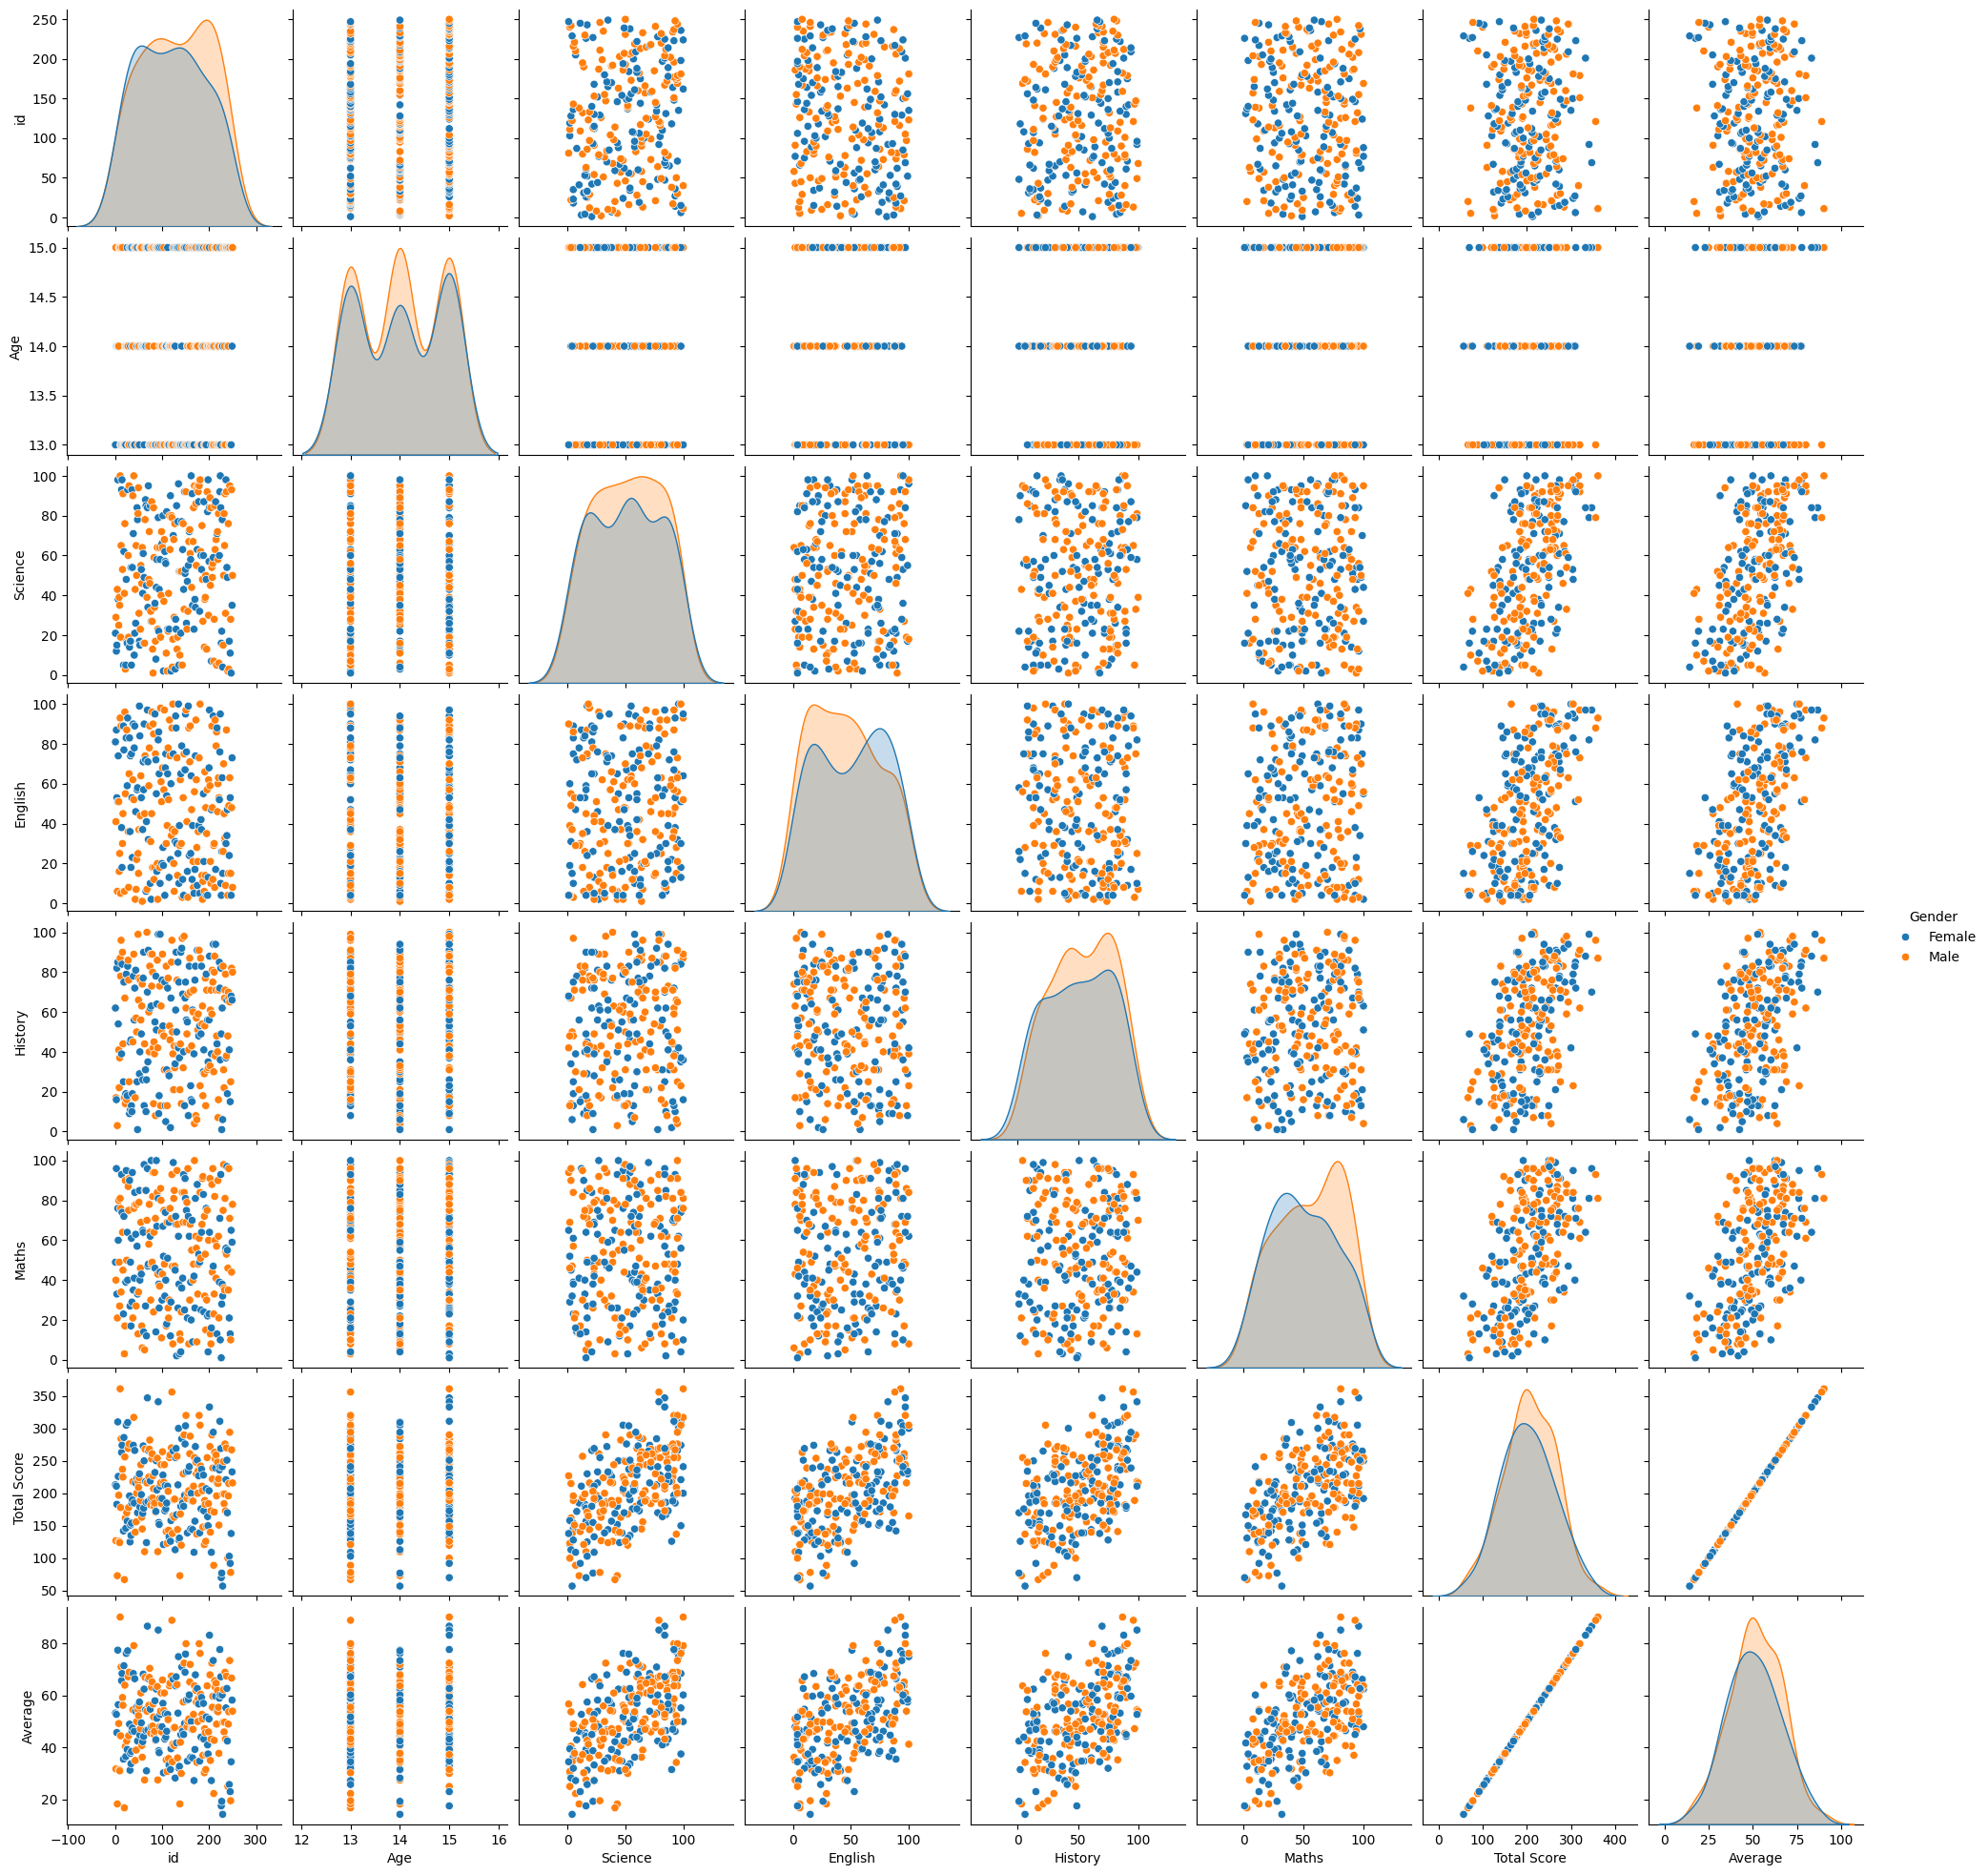

In [48]:
sns.pairplot(df,hue = 'Gender')
plt.show()

Insights:
From the above plot it is clear that all the scores increase linearly with each other.

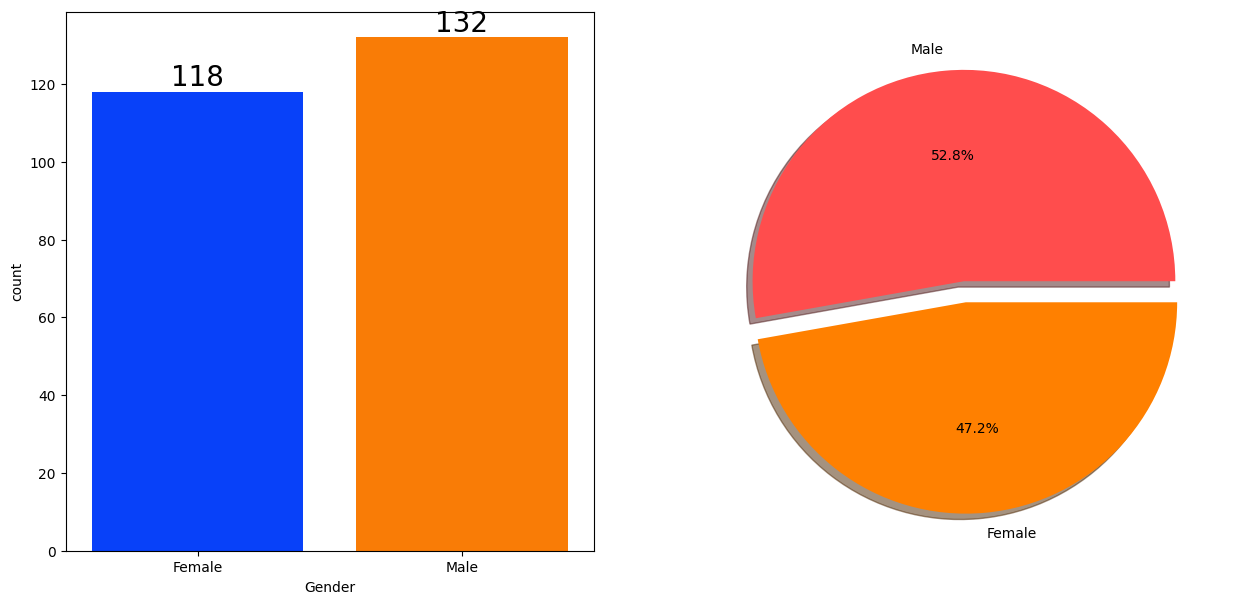

In [70]:
f,ax=plt.subplots(1,2,figsize=(15,7))
sns.countplot(x=df['Gender'],data=df,palette ='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x=df['Gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'])
plt.show()


Insight:
Gender has balanced data with female students are 118 (47.2%) and male students are 132 (52.8%)